# Modeling 30-Day Readmission Risk

This notebook uses the cleaned dataset to train and evaluate models for predicting 30-day hospital readmissions.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

df = pd.read_csv("../data/diabetes_clean.csv")

## Feature Selection

I selected a subset of features that capture patient demographics, clinical indicators, medications, and prior hospital utilization.

Categorical variables were encoded using one-hot encoding before training the models.

## Baseline Model: Logistic Regression

I started with logistic regression as a baseline since it’s simple and easy to interpret and perfect for a binary classification problem like this.

### First Iteration with Logistic Regression, less features

In [2]:
X = df[[
    "time_in_hospital",
    "num_lab_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]]

y = df["readmit_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6302717887305351
              precision    recall  f1-score   support

           0       0.91      0.73      0.81     18083
           1       0.17      0.45      0.25      2271

    accuracy                           0.70     20354
   macro avg       0.54      0.59      0.53     20354
weighted avg       0.83      0.70      0.75     20354



### Second Iteration with Logistic Regression, slightly more features

In [3]:
X = df[
    [
        "time_in_hospital",
        "num_lab_procedures",
        "num_medications",
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "age",
        "gender"
    ]
]

X = pd.get_dummies(X, drop_first=True)
y = df["readmit_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6389229170360371
              precision    recall  f1-score   support

           0       0.92      0.71      0.80     18083
           1       0.17      0.47      0.25      2271

    accuracy                           0.69     20354
   macro avg       0.54      0.59      0.53     20354
weighted avg       0.83      0.69      0.74     20354



### Third Iteration with Logistic Regression, more features and slight increase to ROC-AUC

In [4]:
X = df[
    [
        "time_in_hospital",
        "num_lab_procedures",
        "num_medications",
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "age",
        "gender",
        "A1Cresult",
        "max_glu_serum",
        "insulin",
        "change",
        "diabetesMed"
    ]
]

X = pd.get_dummies(X, drop_first=True)

# clean column names
X.columns = (
    X.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "lt_", regex=False)
    .str.replace(">", "gt_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("-", "_", regex=False)
)

y = df["readmit_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.6394531424925912
              precision    recall  f1-score   support

           0       0.92      0.70      0.80     18083
           1       0.17      0.49      0.25      2271

    accuracy                           0.68     20354
   macro avg       0.54      0.59      0.52     20354
weighted avg       0.83      0.68      0.74     20354



Even when adding more features, it seems that the performance plateaued using Logistic Regression. Now, I switched to XGBoost to see if the nonlinear relations can be captured and improve performance. 

## Improved Model: XGBoost

I then used XGBoost to capture more complex patterns in the data. Since it builds trees sequentially, it can model nonlinear relationships and interactions between features more effectively.

This generally works better for structured datasets like this one.

In [5]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.644697466618345
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.54      0.25      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.71     20354



## Threshold Tuning

Because the dataset is imbalanced, adjusting the classification threshold has a big impact on results.

Lower thresholds increase recall (more high-risk patients are flagged), but also increase false positives, an important tradeoff in a clinical setting.

In [6]:
for t in [0.5, 0.4, 0.3]:
    y_pred = (y_proba > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.54      0.25      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.71     20354


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.94      0.30      0.45     18083
           1       0.13      0.85      0.23      2271

    accuracy                           0.36     20354
   macro avg       0.54      0.57      0.34     20354
weighted avg       0.85      0.36      0.43     20354


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.96      0.05      0.10     18083
           1       0.12      0.98      0.21      2271

    accuracy                           0.16     20354
   macro avg       0.54      0.52      0.15     20354
weighted avg       0.87   

## Feature Importance

Feature importance from the XGBoost model helps show what’s driving predictions.

Prior inpatient visits stand out as the strongest signal, along with emergency visits, length of stay, and indicators of disease severity.

In [7]:
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

,feature,importance
5,number_inpatient,0.289776
25,diabetesMed_Yes,0.061807
13,age_80_90,0.045627
0,time_in_hospital,0.042859
10,age_50_60,0.042578
12,age_70_80,0.038950
8,age_30_40,0.037807
21,insulin_No,0.034366
17,A1Cresult_gt_8,0.031624
4,number_emergency,0.031121


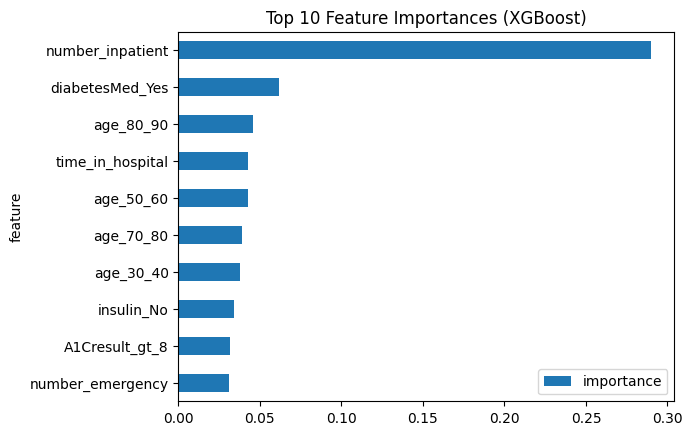

In [8]:
feat_imp.sort_values(by="importance").tail(10).plot(
    kind="barh", x="feature", y="importance"
)
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

## ROC Curve

The ROC curve shows how well the model separates patients who are readmitted from those who are not across different thresholds.

The AUC is around 0.64, which suggests moderate predictive ability.

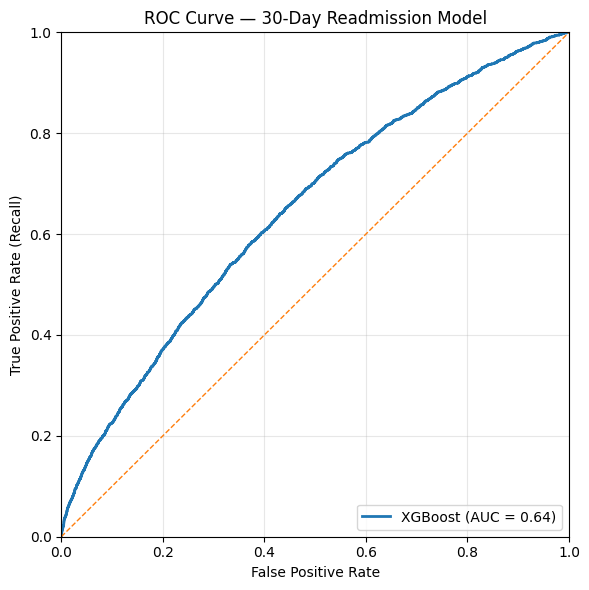

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"XGBoost (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — 30-Day Readmission Model")

plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.style.use("default")
plt.tight_layout()
plt.savefig("../images/roc_curve.png", dpi=300)
plt.show()

## Clinical Interpretation

The model suggests that readmission risk is largely driven by:

- prior hospital utilization  
- disease severity  
- patient demographics  

This lines up with what someone would expect — patients who are frequently hospitalized or have poorly controlled conditions are more likely to return.

## Conclusion

This project walks through an end-to-end workflow for predicting hospital readmissions using structured data.

XGBoost performed better than the logistic regression baseline, especially in identifying high-risk patients, but overall performance is still moderate.

There’s room to improve by incorporating temporal data or additional clinical context.